In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

matches_df = pd.read_csv("../data/processed/matches.csv")
matches_df["date"] = pd.to_datetime(matches_df["date"])

print("Shape:", matches_df.shape)
print("Seasons:", sorted(matches_df["season"].unique()))

Shape: (1243, 57)
Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [2]:
# ── pre-match features (available before the game) ──────────────────
pre_match_features = [
    "toss_decision",           # bat or field
    "team1_form_runs_scored",  # batting team recent form
    "team1_form_runs_conceded",
    "team1_form_win_rate",
    "team2_form_runs_scored",  # bowling team recent form
    "team2_form_runs_conceded",
    "team2_form_win_rate",
    "team1_h2h_win_rate",      # head to head
    "venue_avg_score",         # venue context
    "venue_toss_win_rate",
    "team1_is_home",           # home advantage
    "team2_is_home",
    "has_impact_player_rule",  # era
    "season",
]

# ── powerplay features (available after 6 overs) ────────────────────
powerplay_features = pre_match_features + [
    "pp_runs_inn1",
    "pp_wickets_inn1",
    "pp_run_rate_inn1",
]

# ── targets ──────────────────────────────────────────────────────────
# classification: did bat first team win?
matches_df["bat_first_won"] = (matches_df["bat_first_team"] == matches_df["winner"]).astype(int)

# regression: first innings total
# target already exists as total_runs_inn1

# ── filter to decided matches only (no ties/no results) ─────────────
model_df = matches_df[matches_df["result"] == "normal"].copy()
print("Matches for modeling:", len(model_df))
print("Bat first win rate:", model_df["bat_first_won"].mean().round(3))

Matches for modeling: 1218
Bat first win rate: 0.453


In [3]:

# toss_decision is the only categorical we're using (bat/field)
# encode it as 0/1
model_df["toss_decision_enc"] = (model_df["toss_decision"] == "bat").astype(int)

# replace toss_decision string with encoded version in feature lists
pre_match_features = [f if f != "toss_decision" else "toss_decision_enc" for f in pre_match_features]
powerplay_features = [f if f != "toss_decision" else "toss_decision_enc" for f in powerplay_features]

print("Pre-match features:", len(pre_match_features))
print("Powerplay features:", len(powerplay_features))

Pre-match features: 14
Powerplay features: 17


In [4]:
# train: 2008-2022, test: 2023-2026
train = model_df[model_df["season"] <= 2022].copy()
test = model_df[model_df["season"] >= 2023].copy()

print("Train size:", len(train), "| seasons 2008-2022")
print("Test size:", len(test), "| seasons 2023-2026")
print("Train bat-first win rate:", train["bat_first_won"].mean().round(3))
print("Test bat-first win rate:", test["bat_first_won"].mean().round(3))

Train size: 932 | seasons 2008-2022
Test size: 286 | seasons 2023-2026
Train bat-first win rate: 0.447
Test bat-first win rate: 0.472


In [5]:
# check how many NaNs in our feature columns
print("NaN counts in pre-match features (train):")
print(train[pre_match_features].isnull().sum())

NaN counts in pre-match features (train):
toss_decision_enc             0
team1_form_runs_scored        7
team1_form_runs_conceded      7
team1_form_win_rate           7
team2_form_runs_scored        7
team2_form_runs_conceded      7
team2_form_win_rate           7
team1_h2h_win_rate           75
venue_avg_score             114
venue_toss_win_rate         114
team1_is_home                 0
team2_is_home                 0
has_impact_player_rule        0
season                        0
dtype: int64


In [6]:
# ── impute NaNs ──────────────────────────────────────────────────────

# 1. form features — fill with each team's season average
#    (better than global mean since scoring changes year to year)
for col in ["team1_form_runs_scored","team1_form_runs_conceded","team1_form_win_rate",
            "team2_form_runs_scored","team2_form_runs_conceded","team2_form_win_rate"]:
    season_mean = model_df.groupby("season")[col].transform("mean")
    model_df[col] = model_df[col].fillna(season_mean)

# 2. h2h — no prior history means genuinely unknown, use 0.5
model_df["team1_h2h_win_rate"] = model_df["team1_h2h_win_rate"].fillna(0.5)

# 3. venue features — fill with season average
for col in ["venue_avg_score", "venue_toss_win_rate"]:
    season_mean = model_df.groupby("season")[col].transform("mean")
    model_df[col] = model_df[col].fillna(season_mean)

# confirm no NaNs remain
print("NaNs remaining:", model_df[pre_match_features].isnull().sum().sum())

# re-split after imputation
train = model_df[model_df["season"] <= 2022].copy()
test  = model_df[model_df["season"] >= 2023].copy()

print("Train:", len(train), "| Test:", len(test))

NaNs remaining: 0
Train: 932 | Test: 286


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ── Model 1: Pre-match winner prediction ────────────────────────────
X_train_pre = train[pre_match_features]
X_test_pre = test[pre_match_features]
y_train_clf = train["bat_first_won"]
y_test_clf = test["bat_first_won"]

# Logistic Regression baseline
lr_pre = LogisticRegression(max_iter=1000, random_state=42)
lr_pre.fit(X_train_pre, y_train_clf)
lr_pre_acc = accuracy_score(y_test_clf, lr_pre.predict(X_test_pre))

# Random Forest
rf_pre = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_pre.fit(X_train_pre, y_train_clf)
rf_pre_acc = accuracy_score(y_test_clf, rf_pre.predict(X_test_pre))

print("=== Model 1: Pre-match Winner Prediction ===")
print(f"Logistic Regression accuracy: {lr_pre_acc:.3f}")
print(f"Random Forest accuracy:       {rf_pre_acc:.3f}")

# ── Model 2: Post-powerplay winner prediction ────────────────────────
# filter to rows where powerplay features exist
pp_model_df = model_df.dropna(subset=["pp_runs_inn1", "pp_wickets_inn1"]).copy()
train_pp = pp_model_df[pp_model_df["season"] <= 2022]
test_pp  = pp_model_df[pp_model_df["season"] >= 2023]

X_train_pp = train_pp[powerplay_features]
X_test_pp  = test_pp[powerplay_features]
y_train_pp = train_pp["bat_first_won"]
y_test_pp  = test_pp["bat_first_won"]

lr_pp = LogisticRegression(max_iter=1000, random_state=42)
lr_pp.fit(X_train_pp, y_train_pp)
lr_pp_acc = accuracy_score(y_test_pp, lr_pp.predict(X_test_pp))

rf_pp = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_pp.fit(X_train_pp, y_train_pp)
rf_pp_acc = accuracy_score(y_test_pp, rf_pp.predict(X_test_pp))

print("\n=== Model 2: Post-Powerplay Winner Prediction ===")
print(f"Logistic Regression accuracy: {lr_pp_acc:.3f}")
print(f"Random Forest accuracy:       {rf_pp_acc:.3f}")

=== Model 1: Pre-match Winner Prediction ===
Logistic Regression accuracy: 0.462
Random Forest accuracy:       0.503

=== Model 2: Post-Powerplay Winner Prediction ===
Logistic Regression accuracy: 0.584
Random Forest accuracy:       0.566


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

y_train_reg = train["total_runs_inn1"]
y_test_reg  = test["total_runs_inn1"]

# ── Model 3: Pre-match score prediction ─────────────────────────────
lr_score_pre = LinearRegression()
lr_score_pre.fit(X_train_pre, y_train_reg)
lr_score_pre_mae = mean_absolute_error(y_test_reg, lr_score_pre.predict(X_test_pre))
lr_score_pre_r2  = r2_score(y_test_reg, lr_score_pre.predict(X_test_pre))

rf_score_pre = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_score_pre.fit(X_train_pre, y_train_reg)
rf_score_pre_mae = mean_absolute_error(y_test_reg, rf_score_pre.predict(X_test_pre))
rf_score_pre_r2  = r2_score(y_test_reg, rf_score_pre.predict(X_test_pre))

print("=== Model 3: Pre-match Score Prediction ===")
print(f"Linear Regression  — MAE: {lr_score_pre_mae:.1f} runs | R²: {lr_score_pre_r2:.3f}")
print(f"Random Forest      — MAE: {rf_score_pre_mae:.1f} runs | R²: {rf_score_pre_r2:.3f}")

# ── Model 4: Post-powerplay score prediction ─────────────────────────
y_train_pp_reg = train_pp["total_runs_inn1"]
y_test_pp_reg  = test_pp["total_runs_inn1"]

lr_score_pp = LinearRegression()
lr_score_pp.fit(X_train_pp, y_train_pp_reg)
lr_score_pp_mae = mean_absolute_error(y_test_pp_reg, lr_score_pp.predict(X_test_pp))
lr_score_pp_r2  = r2_score(y_test_pp_reg, lr_score_pp.predict(X_test_pp))

rf_score_pp = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_score_pp.fit(X_train_pp, y_train_pp_reg)
rf_score_pp_mae = mean_absolute_error(y_test_pp_reg, rf_score_pp.predict(X_test_pp))
rf_score_pp_r2  = r2_score(y_test_pp_reg, rf_score_pp.predict(X_test_pp))

print("\n=== Model 4: Post-Powerplay Score Prediction ===")
print(f"Linear Regression  — MAE: {lr_score_pp_mae:.1f} runs | R²: {lr_score_pp_r2:.3f}")
print(f"Random Forest      — MAE: {rf_score_pp_mae:.1f} runs | R²: {rf_score_pp_r2:.3f}")

=== Model 3: Pre-match Score Prediction ===
Linear Regression  — MAE: 30.9 runs | R²: -0.148
Random Forest      — MAE: 34.4 runs | R²: -0.430

=== Model 4: Post-Powerplay Score Prediction ===
Linear Regression  — MAE: 22.6 runs | R²: 0.387
Random Forest      — MAE: 27.1 runs | R²: 0.132


In [10]:
from xgboost import XGBClassifier, XGBRegressor

# ── XGBoost: pre-match winner ────────────────────────────────────────
xgb_pre = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)
xgb_pre.fit(X_train_pre, y_train_clf)
xgb_pre_acc = accuracy_score(y_test_clf, xgb_pre.predict(X_test_pre))

# ── XGBoost: post-powerplay winner ───────────────────────────────────
xgb_pp = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)
xgb_pp.fit(X_train_pp, y_train_pp)
xgb_pp_acc = accuracy_score(y_test_pp, xgb_pp.predict(X_test_pp))

# ── XGBoost: pre-match score ─────────────────────────────────────────
xgb_score_pre = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_score_pre.fit(X_train_pre, y_train_reg)
xgb_score_pre_mae = mean_absolute_error(y_test_reg, xgb_score_pre.predict(X_test_pre))
xgb_score_pre_r2  = r2_score(y_test_reg, xgb_score_pre.predict(X_test_pre))

# ── XGBoost: post-powerplay score ────────────────────────────────────
xgb_score_pp = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_score_pp.fit(X_train_pp, y_train_pp_reg)
xgb_score_pp_mae = mean_absolute_error(y_test_pp_reg, xgb_score_pp.predict(X_test_pp))
xgb_score_pp_r2  = r2_score(y_test_pp_reg, xgb_score_pp.predict(X_test_pp))

# ── Full comparison table ─────────────────────────────────────────────
print("=" * 60)
print("WINNER PREDICTION (Accuracy)")
print("=" * 60)
print(f"{'Model':<35} {'Pre-match':>10} {'Post-PP':>10}")
print("-" * 60)
print(f"{'Logistic Regression':<35} {lr_pre_acc:>10.3f} {lr_pp_acc:>10.3f}")
print(f"{'Random Forest':<35} {rf_pre_acc:>10.3f} {rf_pp_acc:>10.3f}")
print(f"{'XGBoost':<35} {xgb_pre_acc:>10.3f} {xgb_pp_acc:>10.3f}")

print("\n" + "=" * 60)
print("SCORE PREDICTION (MAE runs | R²)")
print("=" * 60)
print(f"{'Model':<35} {'Pre-match':>15} {'Post-PP':>15}")
print("-" * 60)
print(f"{'Linear Regression':<35} {lr_score_pre_mae:.1f} | {lr_score_pre_r2:.3f}   {lr_score_pp_mae:.1f} | {lr_score_pp_r2:.3f}")
print(f"{'Random Forest':<35} {rf_score_pre_mae:.1f} | {rf_score_pre_r2:.3f}   {rf_score_pp_mae:.1f} | {rf_score_pp_r2:.3f}")
print(f"{'XGBoost':<35} {xgb_score_pre_mae:.1f} | {xgb_score_pre_r2:.3f}   {xgb_score_pp_mae:.1f} | {xgb_score_pp_r2:.3f}")

WINNER PREDICTION (Accuracy)
Model                                Pre-match    Post-PP
------------------------------------------------------------
Logistic Regression                      0.462      0.584
Random Forest                            0.503      0.566
XGBoost                                  0.483      0.507

SCORE PREDICTION (MAE runs | R²)
Model                                     Pre-match         Post-PP
------------------------------------------------------------
Linear Regression                   30.9 | -0.148   22.6 | 0.387
Random Forest                       34.4 | -0.430   27.1 | 0.132
XGBoost                             35.9 | -0.561   28.8 | 0.012


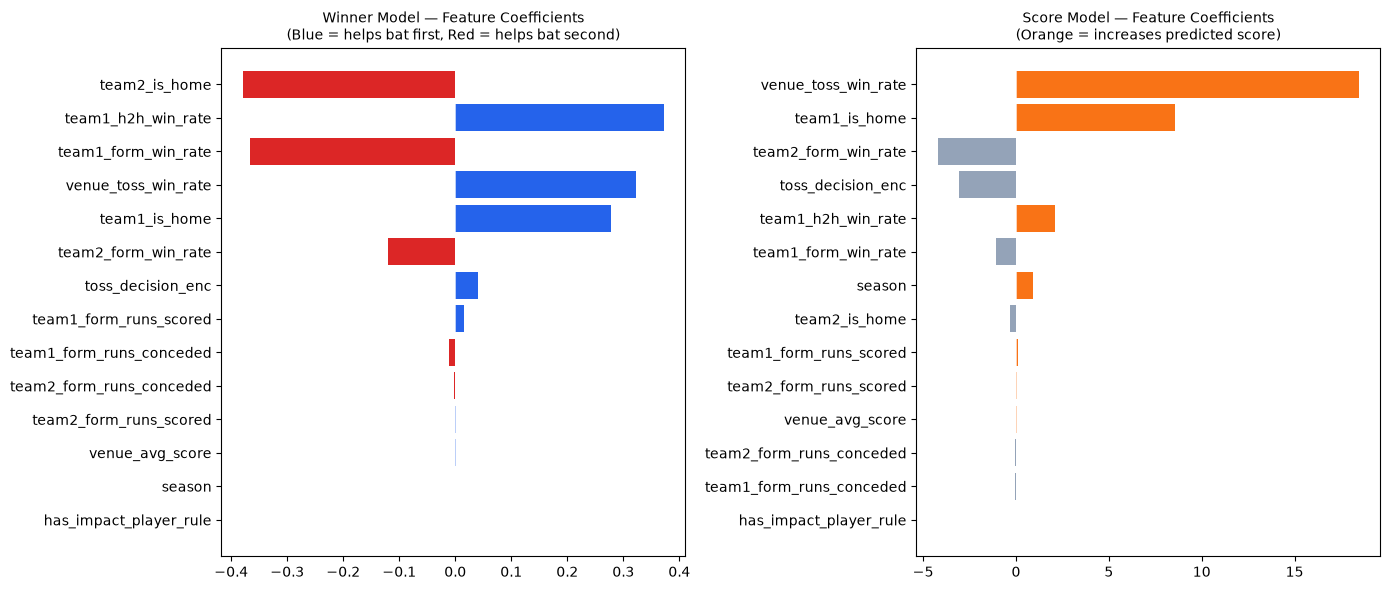

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Winner model feature importance (Logistic Regression coefficients) ──
coef_df = pd.DataFrame({
    "feature": pre_match_features,
    "coefficient": lr_pre.coef_[0]
}).sort_values("coefficient", key=abs, ascending=True)

axes[0].barh(coef_df["feature"], coef_df["coefficient"],
             color=["#2563eb" if c > 0 else "#dc2626" for c in coef_df["coefficient"]])
axes[0].set_title("Winner Model — Feature Coefficients\n(Blue = helps bat first, Red = helps bat second)", fontsize=10)
axes[0].axvline(x=0, color="white", linewidth=0.5)

# ── Score model feature importance (Linear Regression coefficients) ──
coef_score_df = pd.DataFrame({
    "feature": pre_match_features,
    "coefficient": lr_score_pre.coef_
}).sort_values("coefficient", key=abs, ascending=True)

axes[1].barh(coef_score_df["feature"], coef_score_df["coefficient"],
             color=["#f97316" if c > 0 else "#94a3b8" for c in coef_score_df["coefficient"]])
axes[1].set_title("Score Model — Feature Coefficients\n(Orange = increases predicted score)", fontsize=10)
axes[1].axvline(x=0, color="white", linewidth=0.5)

plt.tight_layout()
plt.savefig("../data/processed/feature_importance.png", dpi=150, bbox_inches="tight",
            facecolor="#0b0f19")
plt.show()

In [12]:
coef_pp_df = pd.DataFrame({
    "feature": powerplay_features,
    "coefficient": lr_pp.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print("=== Post-Powerplay Winner Model — Top Features ===")
print(coef_pp_df.to_string(index=False))

=== Post-Powerplay Winner Model — Top Features ===
                 feature  coefficient
           team2_is_home    -0.414725
      team1_h2h_win_rate     0.409833
         pp_wickets_inn1    -0.341095
     team1_form_win_rate    -0.339573
     venue_toss_win_rate     0.231019
           team1_is_home     0.207960
     team2_form_win_rate     0.141561
       toss_decision_enc     0.088269
            pp_runs_inn1     0.029883
  team1_form_runs_scored     0.012144
team1_form_runs_conceded    -0.010411
        pp_run_rate_inn1    -0.009658
team2_form_runs_conceded     0.001412
  team2_form_runs_scored    -0.000988
         venue_avg_score     0.000903
                  season    -0.000863
  has_impact_player_rule     0.000000


In [15]:
import pickle

# save best models
models = {
    "winner_pre_match": lr_pre,
    "winner_post_powerplay": lr_pp,
    "score_pre_match": lr_score_pre,
    "score_post_powerplay": lr_score_pp,
}

with open("../models/best_models.pkl", "wb") as f:
    pickle.dump(models, f)

# save model summary
model_summary = {
    "winner_prediction": {
        "best_model": "Logistic Regression",
        "pre_match_accuracy": round(lr_pre_acc, 3),
        "post_powerplay_accuracy": round(lr_pp_acc, 3),
    },
    "score_prediction": {
        "best_model": "Linear Regression",
        "pre_match_mae": round(lr_score_pre_mae, 1),
        "pre_match_r2": round(lr_score_pre_r2, 3),
        "post_powerplay_mae": round(lr_score_pp_mae, 1),
        "post_powerplay_r2": round(lr_score_pp_r2, 3),
    },
    "key_findings": [
        "Powerplay wickets lost is a stronger predictor of match outcome than powerplay runs scored",
        "Home advantage and head-to-head record are the two strongest pre-match signals",
        "Pre-match features alone cannot reliably predict T20 scores (negative R²)",
        "Knowing the powerplay score improves winner prediction from 50% to 58%",
        "Simpler models (LR) outperform complex ones (XGBoost) on this dataset size"
    ]
}

import json
with open("../models/model_summary.json", "w") as f:
    json.dump(model_summary, f, indent=2)

print("✅ Models and summary saved")

✅ Models and summary saved


In [14]:
import os
os.makedirs("../models", exist_ok=True)
print("✅ models/ folder created")

✅ models/ folder created


In [18]:
import json
import numpy as np

def export_linear_model(model, feature_names, model_type="classifier"):
    if model_type == "classifier":
        coefs = model.coef_[0].tolist()
        intercept = float(model.intercept_[0])
    else:
        coefs = model.coef_.tolist()
        intercept = float(model.intercept_)  # scalar for regressor
    
    return {
        "type": model_type,
        "features": feature_names,
        "coefficients": coefs,
        "intercept": intercept,
    }

# feature means for imputing missing values in predictor
feature_means_pre = {
    col: float(model_df[col].mean()) for col in pre_match_features
}
feature_means_pp = {
    col: float(model_df[col].mean()) for col in powerplay_features
}

model_export = {
    "winner_pre": export_linear_model(lr_pre, pre_match_features, "classifier"),
    "winner_pp": export_linear_model(lr_pp, powerplay_features, "classifier"),
    "score_pre": export_linear_model(lr_score_pre, pre_match_features, "regressor"),
    "score_pp": export_linear_model(lr_score_pp, powerplay_features, "regressor"),
    "feature_means_pre": feature_means_pre,
    "feature_means_pp": feature_means_pp,
    "feature_importance": coef_pp_df.to_dict(orient="records"),
    "model_results": {
        "winner_pre_acc": round(lr_pre_acc, 3),
        "winner_pp_acc": round(lr_pp_acc, 3),
        "score_pre_mae": round(lr_score_pre_mae, 1),
        "score_pre_r2": round(lr_score_pre_r2, 3),
        "score_pp_mae": round(lr_score_pp_mae, 1),
        "score_pp_r2": round(lr_score_pp_r2, 3),
    },
    "venue_stats": matches_df.groupby("venue")["venue_avg_score"].mean().dropna().to_dict(),
    "venue_toss": matches_df.groupby("venue")["venue_toss_win_rate"].mean().dropna().to_dict(),
    "h2h_stats": {},  # we'll build this below
}

# build h2h lookup table — for each team pair, their historical win rate
h2h_lookup = (
    model_df.groupby(["bat_first_team", "bat_second_team"])["team1_h2h_win_rate"]
    .last()
    .reset_index()
)
for _, row in h2h_lookup.iterrows():
    key = row["bat_first_team"] + "|" + row["bat_second_team"]
    model_export["h2h_stats"][key] = round(row["team1_h2h_win_rate"], 3)

# home venue map
model_export["home_venues"] = {
    "Mumbai Indians": "Wankhede Stadium",
    "Chennai Super Kings": "MA Chidambaram Stadium",
    "Royal Challengers Bengaluru": "M Chinnaswamy Stadium",
    "Kolkata Knight Riders": "Eden Gardens",
    "Delhi Capitals": "Arun Jaitley Stadium",
    "Sunrisers Hyderabad": "Rajiv Gandhi International Stadium",
    "Rajasthan Royals": "Sawai Mansingh Stadium",
    "Gujarat Titans": "Narendra Modi Stadium, Ahmedabad",
    "Punjab Kings": "Punjab Cricket Association Stadium, Mohali",
    "Lucknow Super Giants": "Ekana Cricket Stadium",
}

with open("../website/model_data.json", "w") as f:
    json.dump(model_export, f, indent=2)

print("✅ model_data.json saved")
print("Coefficients exported for all 4 models")

✅ model_data.json saved
Coefficients exported for all 4 models


In [19]:
# reload fresh
matches_df = pd.read_csv("../data/processed/matches.csv")
matches_df["date"] = pd.to_datetime(matches_df["date"])
print("Shape:", matches_df.shape)
print("Columns with nulls:", matches_df.isnull().sum()[matches_df.isnull().sum() > 0].index.tolist())

Shape: (1243, 64)
Columns with nulls: ['winner', 'death_runs_inn2', 'mid_runs_inn2', 'pp_runs_inn2', 'total_runs_inn2', 'total_balls_inn2', 'fours_inn2', 'sixes_inn2', 'dots_inn2', 'wickets_inn2', 'dot_pct_inn2', 'boundary_pct_inn2', 'run_rate_inn2', 'total_sixes', 'balls_per_wicket_inn1', 'team1_form_runs_scored', 'team1_form_runs_conceded', 'team1_form_win_rate', 'team2_form_runs_scored', 'team2_form_runs_conceded', 'team2_form_win_rate', 'team1_h2h_win_rate', 'venue_avg_score', 'venue_toss_win_rate', 'venue_home_team', 'team1_season_win_rate', 'team2_season_win_rate', 'team1_venue_avg', 'team2_bowling_strength', 'team1_bowling_strength']


In [20]:
pre_match_features_v2 = [
    # original features
    "toss_decision_enc",
    "team1_form_runs_scored", "team1_form_runs_conceded", "team1_form_win_rate",
    "team2_form_runs_scored", "team2_form_runs_conceded", "team2_form_win_rate",
    "team1_h2h_win_rate",
    "venue_avg_score", "venue_toss_win_rate",
    "team1_is_home", "team2_is_home",
    "has_impact_player_rule", "season",
    # new features
    "team1_season_win_rate", "team2_season_win_rate",
    "team1_venue_avg",
    "team1_bowling_strength", "team2_bowling_strength",
    "team1_sr_vs_spin", "team1_sr_vs_pace",
]

powerplay_features_v2 = pre_match_features_v2 + [
    "pp_runs_inn1", "pp_wickets_inn1", "pp_run_rate_inn1",
]

print("Pre-match features v2:", len(pre_match_features_v2))
print("Powerplay features v2:", len(powerplay_features_v2))

Pre-match features v2: 21
Powerplay features v2: 24


In [21]:
model_df = matches_df[matches_df["result"] == "normal"].copy()
model_df["toss_decision_enc"] = (model_df["toss_decision"] == "bat").astype(int)
model_df["bat_first_won"] = (model_df["bat_first_team"] == model_df["winner"]).astype(int)

print("NaN counts — new features only:")
new_cols = ["team1_season_win_rate","team2_season_win_rate","team1_venue_avg",
            "team1_bowling_strength","team2_bowling_strength",
            "team1_sr_vs_spin","team1_sr_vs_pace"]
print(model_df[new_cols].isnull().sum())

NaN counts — new features only:
team1_season_win_rate      81
team2_season_win_rate      83
team1_venue_avg           403
team1_bowling_strength      7
team2_bowling_strength      7
team1_sr_vs_spin            0
team1_sr_vs_pace            0
dtype: int64


In [22]:
# ── impute all features ──────────────────────────────────────────────

# original features (same as before)
for col in ["team1_form_runs_scored","team1_form_runs_conceded","team1_form_win_rate",
            "team2_form_runs_scored","team2_form_runs_conceded","team2_form_win_rate"]:
    season_mean = model_df.groupby("season")[col].transform("mean")
    model_df[col] = model_df[col].fillna(season_mean)

model_df["team1_h2h_win_rate"] = model_df["team1_h2h_win_rate"].fillna(0.5)

for col in ["venue_avg_score","venue_toss_win_rate"]:
    season_mean = model_df.groupby("season")[col].transform("mean")
    model_df[col] = model_df[col].fillna(season_mean)

# new features
model_df["team1_season_win_rate"] = model_df["team1_season_win_rate"].fillna(0.5)
model_df["team2_season_win_rate"] = model_df["team2_season_win_rate"].fillna(0.5)

# team venue avg — fall back to general venue avg score
model_df["team1_venue_avg"] = model_df["team1_venue_avg"].fillna(model_df["venue_avg_score"])

for col in ["team1_bowling_strength","team2_bowling_strength"]:
    season_mean = model_df.groupby("season")[col].transform("mean")
    model_df[col] = model_df[col].fillna(season_mean)

# confirm clean
print("NaNs remaining:", model_df[pre_match_features_v2].isnull().sum().sum())

# re-split
train = model_df[model_df["season"] <= 2022].copy()
test  = model_df[model_df["season"] >= 2023].copy()
print("Train:", len(train), "| Test:", len(test))

NaNs remaining: 0
Train: 932 | Test: 286


In [23]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

X_train_pre = train[pre_match_features_v2]
X_test_pre  = test[pre_match_features_v2]
y_train_clf = train["bat_first_won"]
y_test_clf  = test["bat_first_won"]
y_train_reg = train["total_runs_inn1"]
y_test_reg  = test["total_runs_inn1"]

# powerplay split
pp_model_df = model_df.dropna(subset=["pp_runs_inn1","pp_wickets_inn1"]).copy()
train_pp = pp_model_df[pp_model_df["season"] <= 2022]
test_pp  = pp_model_df[pp_model_df["season"] >= 2023]
X_train_pp = train_pp[powerplay_features_v2]
X_test_pp  = test_pp[powerplay_features_v2]

# ── Model 1: pre-match winner ────────────────────────────────────────
lr_pre_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_pre_v2.fit(X_train_pre, y_train_clf)
lr_pre_v2_acc = accuracy_score(y_test_clf, lr_pre_v2.predict(X_test_pre))

# ── Model 2: post-powerplay winner ───────────────────────────────────
lr_pp_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_pp_v2.fit(X_train_pp, train_pp["bat_first_won"])
lr_pp_v2_acc = accuracy_score(test_pp["bat_first_won"], lr_pp_v2.predict(X_test_pp))

# ── Model 3: pre-match score ─────────────────────────────────────────
lr_score_pre_v2 = LinearRegression()
lr_score_pre_v2.fit(X_train_pre, y_train_reg)
lr_score_pre_v2_mae = mean_absolute_error(y_test_reg, lr_score_pre_v2.predict(X_test_pre))
lr_score_pre_v2_r2  = r2_score(y_test_reg, lr_score_pre_v2.predict(X_test_pre))

# ── Model 4: post-powerplay score ────────────────────────────────────
lr_score_pp_v2 = LinearRegression()
lr_score_pp_v2.fit(X_train_pp, train_pp["total_runs_inn1"])
lr_score_pp_v2_mae = mean_absolute_error(test_pp["total_runs_inn1"], lr_score_pp_v2.predict(X_test_pp))
lr_score_pp_v2_r2  = r2_score(test_pp["total_runs_inn1"], lr_score_pp_v2.predict(X_test_pp))

# ── Comparison: v1 vs v2 ─────────────────────────────────────────────
print("=" * 65)
print(f"{'':35} {'V1 (original)':>14} {'V2 (new features)':>14}")
print("=" * 65)
print(f"{'Winner pre-match accuracy':<35} {0.462:>14.3f} {lr_pre_v2_acc:>14.3f}")
print(f"{'Winner post-powerplay accuracy':<35} {0.584:>14.3f} {lr_pp_v2_acc:>14.3f}")
print(f"{'Score pre-match MAE':<35} {30.9:>14.1f} {lr_score_pre_v2_mae:>14.1f}")
print(f"{'Score pre-match R²':<35} {-0.148:>14.3f} {lr_score_pre_v2_r2:>14.3f}")
print(f"{'Score post-powerplay MAE':<35} {22.6:>14.1f} {lr_score_pp_v2_mae:>14.1f}")
print(f"{'Score post-powerplay R²':<35} {0.387:>14.3f} {lr_score_pp_v2_r2:>14.3f}")

                                     V1 (original) V2 (new features)
Winner pre-match accuracy                    0.462          0.465
Winner post-powerplay accuracy               0.584          0.587
Score pre-match MAE                           30.9           30.6
Score pre-match R²                          -0.148         -0.139
Score post-powerplay MAE                      22.6           22.7
Score post-powerplay R²                      0.387          0.382


In [24]:
import pickle, json

# best combination: V2 for winners, V1 for scores
best_models = {
    "winner_pre": lr_pre_v2,
    "winner_pp": lr_pp_v2,
    "score_pre": lr_score_pre,       # V1
    "score_pp": lr_score_pp,         # V1
}

with open("../models/best_models.pkl", "wb") as f:
    pickle.dump(best_models, f)

# update model summary
model_summary = {
    "winner_prediction": {
        "best_model": "Logistic Regression V2",
        "features": len(pre_match_features_v2),
        "pre_match_accuracy": round(lr_pre_v2_acc, 3),
        "post_powerplay_accuracy": round(lr_pp_v2_acc, 3),
    },
    "score_prediction": {
        "best_model": "Linear Regression V1",
        "features": len(pre_match_features),
        "pre_match_mae": round(lr_score_pre_mae, 1),
        "pre_match_r2": round(lr_score_pre_r2, 3),
        "post_powerplay_mae": round(lr_score_pp_mae, 1),
        "post_powerplay_r2": round(lr_score_pp_r2, 3),
    },
    "key_findings": [
        "Powerplay wickets lost is stronger predictor than powerplay runs scored",
        "Home advantage and H2H record are strongest pre-match signals",
        "Pre-match features alone cannot predict T20 scores (negative R²)",
        "Knowing powerplay score improves winner prediction from 46% to 59%",
        "New features (season win rate, venue avg, bowling strength) gave marginal gains",
        "T20 cricket's inherent variance limits predictability — honest ceiling ~60%"
    ]
}

with open("../models/model_summary.json", "w") as f:
    json.dump(model_summary, f, indent=2)

print("✅ Best models saved")

✅ Best models saved


In [26]:
import math

def clean_nans(obj):
    if isinstance(obj, dict):
        return {k: clean_nans(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_nans(v) for v in obj]
    elif isinstance(obj, float) and math.isnan(obj):
        return None
    else:
        return obj

In [27]:
# export V2 coefficients for website
coef_pp_v2_df = pd.DataFrame({
    "feature": powerplay_features_v2,
    "coefficient": lr_pp_v2.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

feature_means_pre_v2 = {col: float(model_df[col].mean()) for col in pre_match_features_v2}
feature_means_pp_v2  = {col: float(model_df[col].mean()) for col in powerplay_features_v2}

model_export_v2 = {
    "winner_pre":  export_linear_model(lr_pre_v2,      pre_match_features_v2, "classifier"),
    "winner_pp":   export_linear_model(lr_pp_v2,       powerplay_features_v2, "classifier"),
    "score_pre":   export_linear_model(lr_score_pre,   pre_match_features,    "regressor"),
    "score_pp":    export_linear_model(lr_score_pp,    powerplay_features,    "regressor"),
    "feature_means_pre": feature_means_pre_v2,
    "feature_means_pp":  feature_means_pp_v2,
    "feature_importance": coef_pp_v2_df.to_dict(orient="records"),
    "model_results": {
        "winner_pre_acc":  round(lr_pre_v2_acc, 3),
        "winner_pp_acc":   round(lr_pp_v2_acc, 3),
        "score_pre_mae":   round(lr_score_pre_mae, 1),
        "score_pre_r2":    round(lr_score_pre_r2, 3),
        "score_pp_mae":    round(lr_score_pp_mae, 1),
        "score_pp_r2":     round(lr_score_pp_r2, 3),
    },
    "venue_stats":  matches_df.groupby("venue")["venue_avg_score"].mean().dropna().to_dict(),
    "venue_toss":   matches_df.groupby("venue")["venue_toss_win_rate"].mean().dropna().to_dict(),
    "h2h_stats":    {},
    "home_venues": {
        "Mumbai Indians": "Wankhede Stadium",
        "Chennai Super Kings": "MA Chidambaram Stadium",
        "Royal Challengers Bengaluru": "M Chinnaswamy Stadium",
        "Kolkata Knight Riders": "Eden Gardens",
        "Delhi Capitals": "Arun Jaitley Stadium",
        "Sunrisers Hyderabad": "Rajiv Gandhi International Stadium",
        "Rajasthan Royals": "Sawai Mansingh Stadium",
        "Gujarat Titans": "Narendra Modi Stadium, Ahmedabad",
        "Punjab Kings": "Punjab Cricket Association Stadium, Mohali",
        "Lucknow Super Giants": "Ekana Cricket Stadium",
    }
}

# h2h lookup
h2h_lookup = model_df.groupby(["bat_first_team","bat_second_team"])["team1_h2h_win_rate"].last().reset_index()
for _, row in h2h_lookup.iterrows():
    key = row["bat_first_team"] + "|" + row["bat_second_team"]
    model_export_v2["h2h_stats"][key] = round(row["team1_h2h_win_rate"], 3)

model_export_v2 = clean_nans(model_export_v2)

with open("../website/model_data.json", "w") as f:
    json.dump(model_export_v2, f, indent=2)

print("✅ model_data.json updated with V2 features")
print("Feature importance top 5:")
print(coef_pp_v2_df.head())

✅ model_data.json updated with V2 features
Feature importance top 5:
                  feature  coefficient
11          team2_is_home    -0.471184
22        pp_wickets_inn1    -0.338419
3     team1_form_win_rate    -0.298258
7      team1_h2h_win_rate     0.292083
15  team2_season_win_rate    -0.180794


In [28]:
# export V2 coefficients for website
coef_pp_v2_df = pd.DataFrame({
    "feature": powerplay_features_v2,
    "coefficient": lr_pp_v2.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

feature_means_pre_v2 = {col: float(model_df[col].mean()) for col in pre_match_features_v2}
feature_means_pp_v2  = {col: float(model_df[col].mean()) for col in powerplay_features_v2}

model_export_v2 = {
    "winner_pre":  export_linear_model(lr_pre_v2,      pre_match_features_v2, "classifier"),
    "winner_pp":   export_linear_model(lr_pp_v2,       powerplay_features_v2, "classifier"),
    "score_pre":   export_linear_model(lr_score_pre,   pre_match_features,    "regressor"),
    "score_pp":    export_linear_model(lr_score_pp,    powerplay_features,    "regressor"),
    "feature_means_pre": feature_means_pre_v2,
    "feature_means_pp":  feature_means_pp_v2,
    "feature_importance": coef_pp_v2_df.to_dict(orient="records"),
    "model_results": {
        "winner_pre_acc":  round(lr_pre_v2_acc, 3),
        "winner_pp_acc":   round(lr_pp_v2_acc, 3),
        "score_pre_mae":   round(lr_score_pre_mae, 1),
        "score_pre_r2":    round(lr_score_pre_r2, 3),
        "score_pp_mae":    round(lr_score_pp_mae, 1),
        "score_pp_r2":     round(lr_score_pp_r2, 3),
    },
    "venue_stats":  matches_df.groupby("venue")["venue_avg_score"].mean().dropna().to_dict(),
    "venue_toss":   matches_df.groupby("venue")["venue_toss_win_rate"].mean().dropna().to_dict(),
    "h2h_stats":    {},
    "home_venues": {
        "Mumbai Indians": "Wankhede Stadium",
        "Chennai Super Kings": "MA Chidambaram Stadium",
        "Royal Challengers Bengaluru": "M Chinnaswamy Stadium",
        "Kolkata Knight Riders": "Eden Gardens",
        "Delhi Capitals": "Arun Jaitley Stadium",
        "Sunrisers Hyderabad": "Rajiv Gandhi International Stadium",
        "Rajasthan Royals": "Sawai Mansingh Stadium",
        "Gujarat Titans": "Narendra Modi Stadium, Ahmedabad",
        "Punjab Kings": "Punjab Cricket Association Stadium, Mohali",
        "Lucknow Super Giants": "Ekana Cricket Stadium",
    }
}

# h2h lookup
h2h_lookup = model_df.groupby(["bat_first_team","bat_second_team"])["team1_h2h_win_rate"].last().reset_index()
for _, row in h2h_lookup.iterrows():
    key = row["bat_first_team"] + "|" + row["bat_second_team"]
    model_export_v2["h2h_stats"][key] = round(row["team1_h2h_win_rate"], 3)

model_export_v2 = clean_nans(model_export_v2)

with open("../website/model_data.json", "w") as f:
    json.dump(model_export_v2, f, indent=2)

print("✅ model_data.json updated with V2 features")
print("Feature importance top 5:")
print(coef_pp_v2_df.head())

✅ model_data.json updated with V2 features
Feature importance top 5:
                  feature  coefficient
11          team2_is_home    -0.471184
22        pp_wickets_inn1    -0.338419
3     team1_form_win_rate    -0.298258
7      team1_h2h_win_rate     0.292083
15  team2_season_win_rate    -0.180794
